# 09 · 안전과 가드레일

**구성요소:** 안전(safety).

> 경로 거부목록: `.env`, 시크릿, `auth/`, `payments/`, `migrations/`, 인프라는 절대 자동으로 편집하지 않는다.
> 사람 게이트(human gate): 보안, 결제, 인프라, 의존성 업그레이드, N개를 넘는 파일 변경, 세 번째 실패한 시도.
> 안티패턴 #9: "허용목록 없는 자동 병합."

**문제 설정** — 루프는 변경안을 만들어 낸다. 어떤 것은 사소하고 안전하며, 어떤 것은 위험한 경로를 건드리거나 덩치가 크다. 사람이 지켜보지 않는 루프는 그 하나하나에 대해 **자동 실행(auto act)할 것인가, 사람에게 넘길 것인가(에스컬레이션)** 를 스스로 정해야 한다. 순진한 정책 — "검증기가 통과시켰으니 병합한다" — 은 위험한 변경까지 자동 실행한다.

**측정 대상** — 표준 안전 정책으로 라벨이 붙은 제안 액션 집합 위에서 두 정책의 **오자동실행률(false-auto-act rate)** 을 잰다. 진짜로 위험한 변경을 사람 확인 없이 실행해 버린 비율이다. 여기에 라우터의 에스컬레이션 정밀도와 재현율을 더한다.

**왜 이 지표인가** — **위험한 변경을 통과시키는 가드레일은 가드레일이 아니다.** 다만 낮은 오자동실행 하나만으로는 아무것도 증명되지 않는다. 아무것도 자동 실행하지 않는 정책도 그 수치를 만점으로 받기 때문이다. 그래서 라우터가 **안전한 일을 여전히 자동으로 흘려보내는지**를 함께 본다.


============================================ 에스컬레이션 라우터 ============================================


*제안된 액션마다 라우팅한다: 안전하고 허용된 것은 자동 실행, 위험한 것은 사람에게*

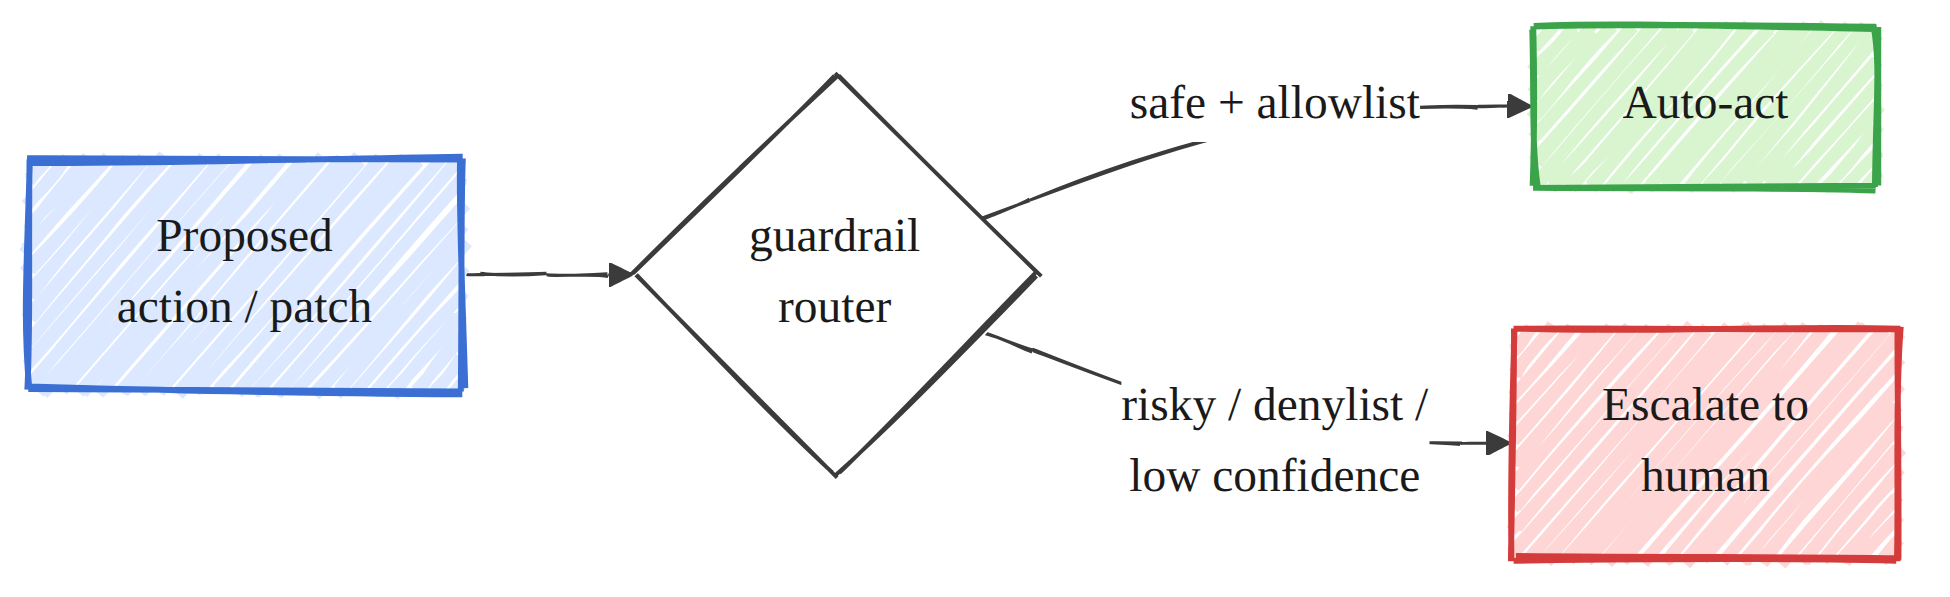

In [1]:
import os
import sys
import random

sys.path.insert(0, os.environ.get("LEN_PROJECT_ROOT", os.path.abspath(".")))

from common import show, eval as ev, plotting, runlog, runtime

# ── 이 노트북은 모델을 한 번도 호출하지 않는다 ─────────────────────
# 액션 집합은 전부 합성 데이터이고 두 정책은 순수 함수다. 그래도 어느
# 환경에서 남긴 기록인지는 남겨 둔다. 백엔드가 없어도 멈추면 안 되므로
# 판별 실패는 삼킨다 — 모델을 쓰지 않는 노트북이라 진행에 지장이 없다.
try:
    rt = runtime.bootstrap(verbose=False)
    ENV_PROVIDER, ENV_MODEL = rt.llm.provider, rt.llm.model
except Exception:
    ENV_PROVIDER, ENV_MODEL = "none", "none"

show.head("에스컬레이션 라우터")
show.diagram("safety_router", "제안된 액션마다 라우팅한다: 안전하고 허용된 것은 자동 실행, 위험한 것은 사람에게")

# ── 안전 정책의 두 목록 ───────────────────────────────────────────
# 거부목록은 '중요한 곳' 목록이 아니라 '되돌리기가 비싸거나 불가능한 곳'
# 목록이다. 이미 적용된 마이그레이션, 유출된 시크릿, 잘못 나간 결제는
# git revert 로 되돌아오지 않는다. 안전 구역은 그 반대 성질을 갖는다.
DENYLIST = ["auth/", "payments/", "billing/", "migrations/", "secrets/", "k8s/production/", ".env"]
SAFE_AREAS = ["docs/", "tests/", "src/util/", "examples/", "README", "src/format/"]


def touches_denylist(path):
    # ⚠️ 함정: 접두사 검사가 아니라 부분 문자열 포함 검사다. "vendor/auth/x.py"
    #    도 걸린다. 안전한 쪽으로 넉넉히 틀리는 선택이라 여기서는 의도된
    #    동작이다. 반대 방향의 실수는 조용해서 더 위험하다 — 거부목록에 없는
    #    새 위험 경로(예: ".github/workflows/")는 이 함수가 영영 못 본다.
    return any(d in path for d in DENYLIST)

## 현실적인 제안 액션 집합

액션 하나는 세 가지를 갖는다 — **경로**, **디프 크기**(변경된 파일 수), **검증기 신뢰도**. 정답 라벨인 "위험함"은 정책을 그대로 따른다.

- 거부목록 경로를 건드리거나,
- 10개를 넘는 파일을 바꾸거나,
- 검증기 신뢰도가 낮다.

아래 두 정책은 이 정답 라벨을 훔쳐보지 않고 수용(자동 실행)과 에스컬레이션을 결정해야 한다.


In [2]:
# ── 제안된 액션 집합을 만든다 ─────────────────────────────────────
# 경로 구성은 안전 구역 6곳 × 6개 + 거부목록 7곳 × 3개로 고정한다.
# 이 비율이 위험한 액션이 3분의 2를 차지하는 적대적인 큐를 만든다.
# 게이트를 시험하려면 위험한 것이 흔해야 한다.
rng = random.Random(7)      # seed 고정: 두 정책이 반드시 같은 큐를 본다
paths = (
    [f"{a}mod_{i}.py" for a in SAFE_AREAS for i in range(6)]
    + [f"{d}mod_{i}.py" for d in DENYLIST for i in range(3)]
)
actions = []
for p in paths:
    # 1 을 두 번 넣은 것은 실제 큐가 작은 변경에 몰려 있기 때문이다.
    # 12 와 20 은 크기 문턱을 실제로 넘겨 보기 위한 꼬리다.
    n_files = rng.choice([1, 1, 2, 3, 5, 8, 12, 20])
    conf = round(rng.uniform(0.5, 0.99), 2)
    # ⚠️ 함정: 여기서 risky 는 정책 그 자체다. 정답 라벨이 정책의 정의에서
    #    유도되므로 라벨 잡음이 없고, 덕분에 게이트의 논리를 깨끗하게 시험할
    #    수 있다. 대신 이 설정에서 나온 오자동실행 수치를 "실제 코드베이스에서도
    #    같다" 로 옮겨 읽으면 안 된다. 현실의 위험 라벨은 이렇게 깔끔하지 않다.
    risky = touches_denylist(p) or n_files > 10 or conf < 0.6
    actions.append({"path": p, "n_files": n_files, "confidence": conf, "risky": risky})
rng.shuffle(actions)        # 경로가 묶여 들어온 순서가 결과에 섞이지 않게 한다
n = len(actions)
n_risky = sum(a["risky"] for a in actions)
show.kv("제안된 액션", n)
show.kv("진짜로 위험한 것 (정책 기준)", n_risky)
show.kv("거부목록 경로", sum(touches_denylist(a["path"]) for a in actions))

  제안된 액션:                    57
  진짜로 위험한 것 (정책 기준):         38
  거부목록 경로:                   21


## 두 정책

- **순진한 정책** — 검증기가 어느 정도 확신하는 것은 무엇이든 자동 실행한다. 경로도 크기도 보지 않는다.
- **가드레일** — 거부목록에 없고 **그리고** 작고(10개 파일 이하) **그리고** 신뢰도가 높을 때(0.8 이상)만 자동 실행한다. 그 밖에는 에스컬레이션한다. **의심스러우면 사람에게 넘기는 것이 기본값이다.**


In [3]:
def naive_autoact(a):
    # 순진한 정책: 축이 하나뿐이다. 검증기가 어느 정도 확신하면 병합한다.
    # 문턱 0.6 은 위험 정의의 신뢰도 하한과 같은 값이라, 신뢰도 축에서는
    # 정확히 맞다. 문제는 나머지 두 축을 아예 보지 않는다는 것이다.
    return a["confidence"] >= 0.6


def guardrail_autoact(a):
    # 가드레일: 성질이 서로 다른 세 검사를 AND 로 묶는다. 어디에 떨어지는가,
    # 폭발 반경이 얼마인가, 행위자 자신이 얼마나 의심하는가.
    # 하나라도 걸리면 그 검사가 단독으로 거부권을 행사한다.
    return (not touches_denylist(a["path"])) and a["n_files"] <= 10 and a["confidence"] >= 0.8


def evaluate(policy):
    auto = [a for a in actions if policy(a)]
    esc = [a for a in actions if not policy(a)]
    false_autoact = sum(1 for a in auto if a["risky"])   # 위험한데 자동 실행했다
    # 위험 클래스를 양성으로 두고 에스컬레이션의 정밀도/재현율을 잰다.
    tp = sum(1 for a in esc if a["risky"])
    fp = sum(1 for a in esc if not a["risky"])
    fn = sum(1 for a in auto if a["risky"])
    pr = ev.prf1(tp, fp, fn)
    # ⚠️ 함정: 오자동실행률의 분모는 '위험한 액션 수'(n_risky)이지 전체 수가
    #    아니다. 전체로 나누면 위험한 것이 드문 큐에서는 어떤 정책이든 좋아
    #    보인다. 그리고 재현율만 보면 '전부 에스컬레이션' 이라는 자명한 정책이
    #    만점을 받는다. 그 자명한 정책과 진짜 라우터를 가르는 것은 정밀도 열,
    #    그리고 auto_acted 열(안전한 일을 여전히 흘려보내는가)이다.
    return {
        "auto_acted": len(auto),
        "escalated": len(esc),
        "false_auto_act": false_autoact,
        "false_auto_act_rate": false_autoact / n_risky if n_risky else 0.0,
        "escalation_precision": pr["precision"],
        "escalation_recall": pr["recall"],
    }
M_naive = evaluate(naive_autoact)
M_guard = evaluate(guardrail_autoact)
show.head("결과")
show.table([
    {"policy": "naive", **{k: round(v, 3) if isinstance(v, float) else v for k, v in M_naive.items()}},
    {"policy": "guardrail", **{k: round(v, 3) if isinstance(v, float) else v for k, v in M_guard.items()}},
], columns=["policy", "auto_acted", "escalated", "false_auto_act", "false_auto_act_rate", "escalation_recall"],
   title="false_auto_act (사람 없이 통과한 위험한 변경)가 핵심 지표다. 낮을수록 좋다")


================================================ 결과 ================================================

------------------------ false_auto_act (사람 없이 통과한 위험한 변경)가 핵심 지표다. 낮을수록 좋다 ------------------------
  policy     auto_acted  escalated  false_auto_act  false_auto_act_rate  escalation_recall
  ---------  ----------  ---------  --------------  -------------------  -----------------
  naive      42          15         23              0.605                0.395            
  guardrail  8           49         0               0.0                  1.0              


## 그래프


  오자동실행률: 가드레일 vs 순진한 정책
    baseline : 0.6053
    treatment: 0.0000
    delta    : -0.6053  (-100.0 percent)  [down, improvement]


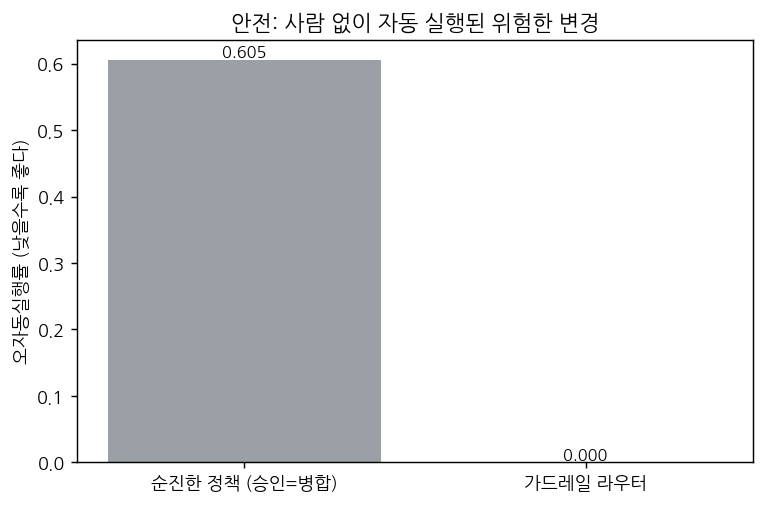

  saved + displayed figure -> /Users/namuai/06-claude/agentic-loop-engineering/agentic-loop-engineering-course-kr/results/figures/09_false_autoact.png


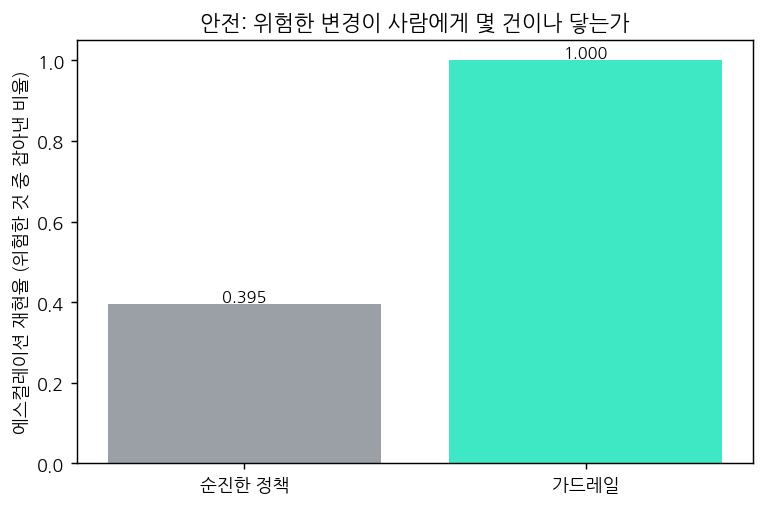

  saved + displayed figure -> /Users/namuai/06-claude/agentic-loop-engineering/agentic-loop-engineering-course-kr/results/figures/09_escalation_recall.png
  saved metrics -> /Users/namuai/06-claude/agentic-loop-engineering/agentic-loop-engineering-course-kr/results/09_safety.json
  logged run -> /Users/namuai/06-claude/agentic-loop-engineering/agentic-loop-engineering-course-kr/results/loop-run-log.json (safety-guardrails: report-only, ~0 tokens)


{'run_id': '2026-08-19T06:41:31Z',
 'pattern': 'safety-guardrails',
 'duration_s': 0.0,
 'items_found': 57,
 'actions_taken': 8,
 'escalations': 49,
 'tokens_estimate': 0,
 'outcome': 'report-only'}

In [4]:
# ── 두 장으로 나눠 그린다 ─────────────────────────────────────────
# 첫 장이 헤드라인(오자동실행률), 둘째 장이 그 0 이 '아무것도 안 해서'
# 얻어진 것이 아님을 확인시켜 주는 재현율이다. 한 장만 그리면 자동화를
# 포기한 라우터와 구분이 되지 않는다.
show.compare("오자동실행률: 가드레일 vs 순진한 정책",
             M_naive["false_auto_act_rate"], M_guard["false_auto_act_rate"],
             higher_is_better=False)
plotting.ab_bar("09_false_autoact", ["순진한 정책 (승인=병합)", "가드레일 라우터"],
                [M_naive["false_auto_act_rate"], M_guard["false_auto_act_rate"]],
                "오자동실행률 (낮을수록 좋다)", "안전: 사람 없이 자동 실행된 위험한 변경")
plotting.ab_bar("09_escalation_recall", ["순진한 정책", "가드레일"],
                [M_naive["escalation_recall"], M_guard["escalation_recall"]],
                "에스컬레이션 재현율 (위험한 것 중 잡아낸 비율)", "안전: 위험한 변경이 사람에게 몇 건이나 닿는가")

runlog.save_metrics("09_safety", {"notebook": "09_safety",
                                  "provider": ENV_PROVIDER,   # 한국어판 추가: 어느 백엔드의 기록인지 남긴다
                                  "model": ENV_MODEL,
                                  "n_actions": n, "n_risky": n_risky,
                                  "naive": M_naive, "guardrail": M_guard})
# 이 노트북에서는 log_run 의 두 인자가 곧 라우터의 두 문이다.
# actions_taken 이 자동 실행, escalations 가 사람에게 넘긴 건수다.
runlog.log_run(pattern="safety-guardrails", duration_s=0, items_found=n,
               actions_taken=M_guard["auto_acted"], escalations=M_guard["escalated"],
               tokens_estimate=0, outcome="report-only")

## 이 실행이 실제로 보여 준 것


In [5]:
show.head("이 실행이 실제로 보여 준 것")
print(f"제안된 액션 {n}건 중 {n_risky}건이 진짜로 위험했다 (거부목록, 큰 변경, 낮은 신뢰도).")
print(f"순진한 정책은 그중 {M_naive['false_auto_act']}건을 자동 실행했다 "
      f"(오자동실행 {M_naive['false_auto_act_rate']:.0%}): 위험한 변경을 병합해 버렸다.")
print(f"가드레일 라우터는 위험한 것을 {M_guard['false_auto_act']}건 자동 실행했고 "
      f"(오자동실행 {M_guard['false_auto_act_rate']:.0%}) 위험한 변경의 {M_guard['escalation_recall']:.0%} 를 에스컬레이션했다.")
print()
# ⚠️ 함정: 아래 결론에서 '검증기 통과' 와 '자동 실행 허가' 를 한 줄로 붙여 읽지 말 것.
#    검증기는 정확성을 판정하고 라우터는 안전성을 판정한다. 두 축을 하나로
#    뭉갠 것이 순진한 정책이고, 그 뭉갬이 위험한 변경을 통과시킨 원인이다.
print("=> 검증기 통과는 필요조건이지 충분조건이 아니다. 사람이 지켜보지 않는 루프가")
print("   auth, payments, migrations 로 자동 병합하는 것을 막아 주는 것은 거부목록 +")
print("   크기 + 신뢰도 게이트다. 기본값은 에스컬레이션이다. 허용목록 없이 자동 병합하지 말 것.")


========================================= 이 실행이 실제로 보여 준 것 =========================================
제안된 액션 57건 중 38건이 진짜로 위험했다 (거부목록, 큰 변경, 낮은 신뢰도).
순진한 정책은 그중 23건을 자동 실행했다 (오자동실행 61%): 위험한 변경을 병합해 버렸다.
가드레일 라우터는 위험한 것을 0건 자동 실행했고 (오자동실행 0%) 위험한 변경의 100% 를 에스컬레이션했다.

=> 검증기 통과는 필요조건이지 충분조건이 아니다. 사람이 지켜보지 않는 루프가
   auth, payments, migrations 로 자동 병합하는 것을 막아 주는 것은 거부목록 +
   크기 + 신뢰도 게이트다. 기본값은 에스컬레이션이다. 허용목록 없이 자동 병합하지 말 것.
